# Appliance Energy Prediction - Exploratory Data Analysis

## Objectives

This notebook covers end-to-end exploratory analysis of the dataset before any modelling begins:

1. Data loading and quality inspection  
2. Target variable distribution and temporal behaviour  
3. STL decomposition - trend, seasonality, and residual components  
4. Temporal and seasonal consumption patterns  
5. Feature correlation analysis  
6. Feature distribution analysis  
7. Outlier detection and treatment  
8. ACF and PACF analysis for lag selection  
9. Summary of all decisions feeding into the next notebook  

All core preprocessing logic is imported from `src/data_preprocessing.py`.

In [1]:
# -------------------------------------------------------
# Add src/ to path so we can import our preprocessing module
# -------------------------------------------------------
import sys
import os

sys.path.append('../src')   # for local Jupyter
# sys.path.append('/content/src')  # uncomment if on Colab

from data_preprocessing import (
    load_data,
    check_data_quality,
    drop_noise_columns,
    clip_outliers_iqr,
    extract_time_features,
    temporal_train_test_split,
    get_feature_columns,
    scale_data
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.seasonal import STL
import warnings

warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

plt.rcParams['figure.dpi']  = 120
plt.rcParams['savefig.dpi'] = 150

COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#A23B72',
    'accent'   : '#F18F01',
    'success'  : '#2ECC71',
    'danger'   : '#E74C3C',
    'neutral'  : '#95A5A6',
}

DATA_PATH      = '../data/raw/energy_data_set.csv'
PROCESSED_PATH = '../data/processed/'
FIGURES_PATH   = '../reports/figures/'

os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(PROCESSED_PATH, exist_ok=True)

print("All imports successful.")

All imports successful.


## 1. Data Loading

We load the raw CSV using `load_data()` from our preprocessing module.
The function parses the datetime column and sorts rows chronologically.

In [2]:
df = load_data(DATA_PATH)

duration = (df['date'].max() - df['date'].min()).days
interval = df['date'].diff().dropna().dt.total_seconds().mode()[0] / 60

print(f"Shape    : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Start    : {df['date'].min()}")
print(f"End      : {df['date'].max()}")
print(f"Duration : {duration} days")
print(f"Interval : {interval:.0f} minutes")

df.head()

Shape    : 19,735 rows x 29 columns
Start    : 2016-01-11 17:00:00
End      : 2016-05-27 18:00:00
Duration : 137 days
Interval : 10 minutes


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## 2. Data Quality Check

We check for missing values, duplicate rows, and the random noise columns `rv1` and `rv2`.

The UCI dataset intentionally includes `rv1` and `rv2` as control columns to test
whether feature selection methods correctly discard them. We will confirm this
by checking their correlation with the target before dropping them.

In [3]:
report = check_data_quality(df)

print("=== DATA QUALITY REPORT ===\n")
print(f"Shape             : {report['shape']}")
print(f"Date Range        : {report['date_range'][0]} to {report['date_range'][1]}")
print(f"Missing Values    : {report['missing_values'] or 'None'}")
print(f"Duplicate Rows    : {report['duplicate_rows']}")
print(f"rv1 == rv2        : {report['rv_columns_identical']}")
print(f"rv1 corr (target) : {report['rv_correlation_with_target'].get('rv1', 'N/A')}")
print(f"rv2 corr (target) : {report['rv_correlation_with_target'].get('rv2', 'N/A')}")
print()
print("Extra columns present vs assessment description:")
extras = ['T7','RH_7','T8','RH_8','T9','RH_9','Tdewpoint']
for c in extras:
    corr = df[c].corr(df['Appliances'])
    print(f"  {c:<12} - corr with Appliances = {corr:.4f}")

=== DATA QUALITY REPORT ===

Shape             : (19735, 29)
Date Range        : 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Missing Values    : None
Duplicate Rows    : 0
rv1 == rv2        : True
rv1 corr (target) : -0.011145
rv2 corr (target) : -0.011145

Extra columns present vs assessment description:
  T7           - corr with Appliances = 0.0258
  RH_7         - corr with Appliances = -0.0556
  T8           - corr with Appliances = 0.0396
  RH_8         - corr with Appliances = -0.0940
  T9           - corr with Appliances = 0.0100
  RH_9         - corr with Appliances = -0.0515
  Tdewpoint    - corr with Appliances = 0.0154


### Quality Findings

- No missing values - no imputation required
- No duplicates - no deduplication required
- `rv1` and `rv2` are identical and have near-zero correlation with the target - **will be dropped**
- The dataset contains 9 room sensors (T1-T9, RH_1-RH_9) instead of 6 as described in the assessment, plus `Tdewpoint` - **all kept** as they provide additional useful information
- `NSM`, `WeekStatus`, and `Day_of_week` are absent from this version - **will be engineered from the date column**

## 3. Target Variable Analysis

`Appliances` is the energy consumption in Wh at each 10-minute interval.
Before any modelling decisions, we need to understand its distribution and identify
whether it is skewed - this directly affects our choice of loss function.

In [ ]:
Q1 = df['Appliances'].quantile(0.25)
Q3 = df['Appliances'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

print("=== TARGET: Appliances (Wh) ===\n")
print(df['Appliances'].describe().round(2).to_string())
print(f"\nSkewness    : {df['Appliances'].skew():.4f}")
print(f"Kurtosis    : {df['Appliances'].kurt():.4f}")
print(f"Upper Fence : {upper_fence:.1f} Wh  (Q3 + 1.5 x IQR)")
print(f"Outliers >  : {(df['Appliances'] > upper_fence).sum()} rows "
      f"({(df['Appliances'] > upper_fence).mean()*100:.2f}%)")
print(df["Appliances"].skew())

print()
print("Decision: Use HUBER LOSS for training.")
print("  Skewness 3.39 means MSE will be dominated by rare high-consumption spikes.")
print("  Huber loss behaves like MSE for small errors and like MAE for large ones.")
print("  We also run one MSE experiment for comparison as the assessment mentions it.")

=== TARGET: Appliances (Wh) ===

count    19735.00
mean        97.69
std        102.52
min         10.00
25%         50.00
50%         60.00
75%        100.00
max       1080.00

Skewness    : 3.3864
Kurtosis    : 13.6679
Upper Fence : 175.0 Wh  (Q3 + 1.5 x IQR)
Outliers >  : 2138 rows (10.83%)

Decision: Use HUBER LOSS for training.
  Skewness 3.39 means MSE will be dominated by rare high-consumption spikes.
  Huber loss behaves like MSE for small errors and like MAE for large ones.
  We also run one MSE experiment for comparison as the assessment mentions it.


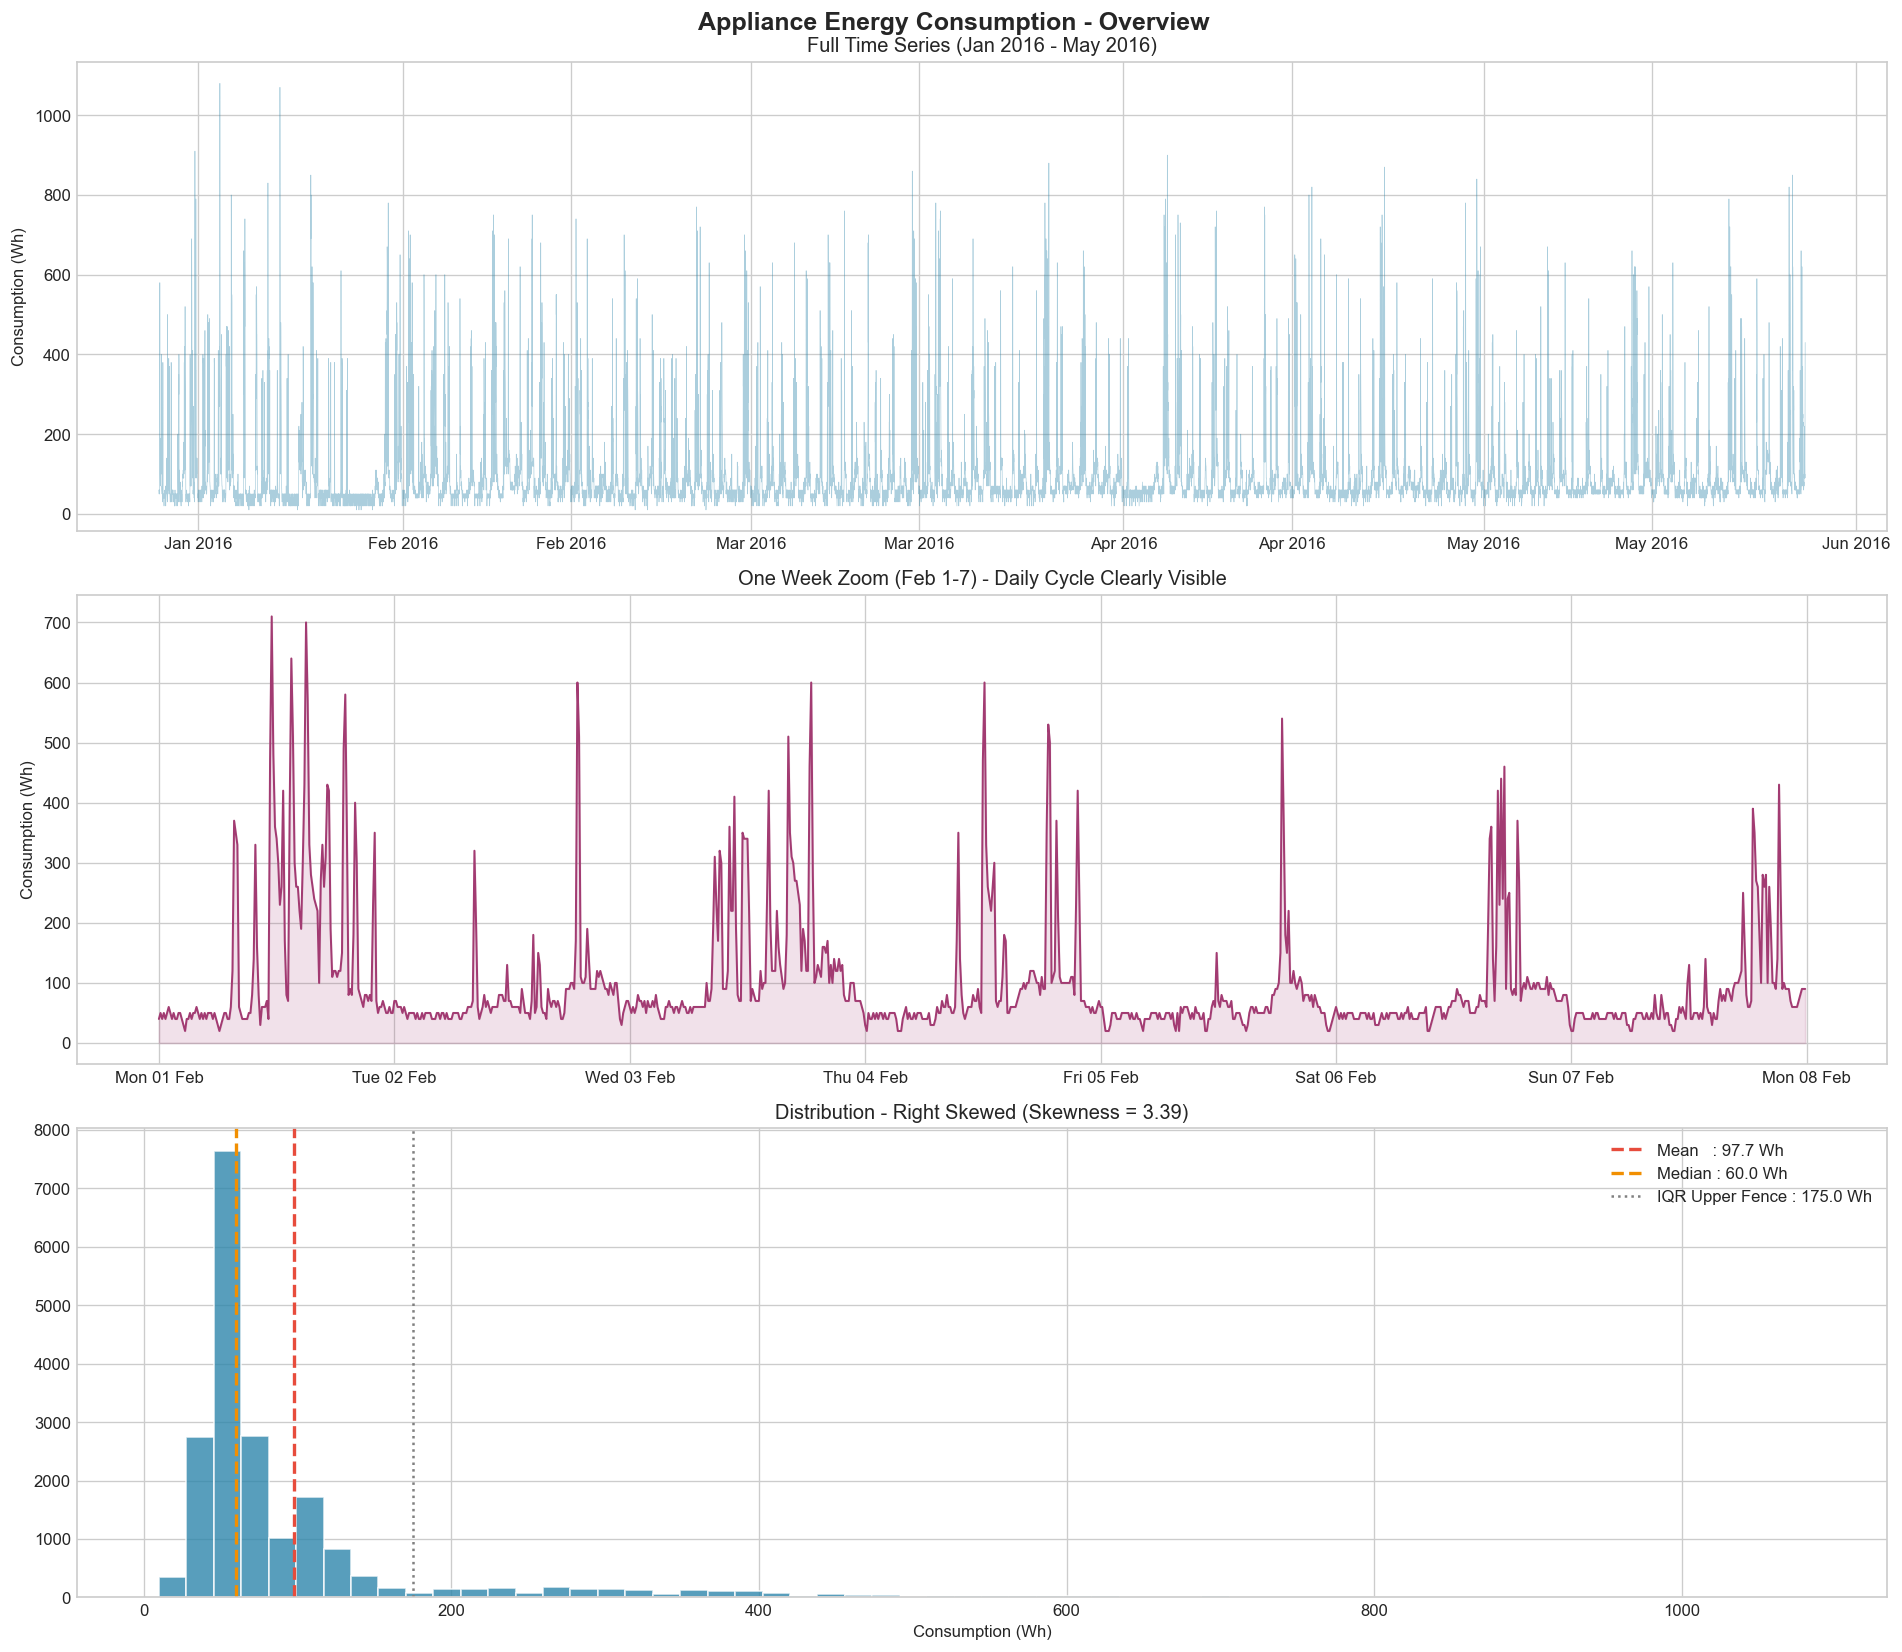

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('Appliance Energy Consumption - Overview', fontsize=15, fontweight='bold')

# Full time series
axes[0].plot(df['date'], df['Appliances'],
             alpha=0.4, color=COLORS['primary'], linewidth=0.4)
axes[0].set_title('Full Time Series (Jan 2016 - May 2016)')
axes[0].set_ylabel('Consumption (Wh)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# One week zoom
wk = df[(df['date'] >= '2016-02-01') & (df['date'] < '2016-02-08')]
axes[1].plot(wk['date'], wk['Appliances'],
             color=COLORS['secondary'], linewidth=1.2)
axes[1].fill_between(wk['date'], wk['Appliances'],
                     alpha=0.15, color=COLORS['secondary'])
axes[1].set_title('One Week Zoom (Feb 1-7) - Daily Cycle Clearly Visible')
axes[1].set_ylabel('Consumption (Wh)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%a %d %b'))

# Distribution
axes[2].hist(df['Appliances'], bins=60,
             color=COLORS['primary'], edgecolor='white', alpha=0.8)
axes[2].axvline(df['Appliances'].mean(),   color=COLORS['danger'],
                linestyle='--', linewidth=2,
                label=f"Mean   : {df['Appliances'].mean():.1f} Wh")
axes[2].axvline(df['Appliances'].median(), color=COLORS['accent'],
                linestyle='--', linewidth=2,
                label=f"Median : {df['Appliances'].median():.1f} Wh")
axes[2].axvline(upper_fence, color='gray', linestyle=':',
                linewidth=1.5,
                label=f"IQR Upper Fence : {upper_fence:.1f} Wh")
axes[2].set_title(f'Distribution - Right Skewed (Skewness = {df["Appliances"].skew():.2f})')
axes[2].set_xlabel('Consumption (Wh)')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}01_target_overview.png', bbox_inches='tight')
plt.show()

## 4. STL Decomposition

STL (Seasonal and Trend decomposition using Loess) breaks the time series into
three interpretable components:

- **Trend** - the long-term direction of energy use over months
- **Seasonal** - the repeating daily pattern (period = 144 steps = 24 hours)
- **Residual** - unexplained variation that no deterministic component captures

This analysis directly justifies our choice of a 24-hour look-back window as the
starting candidate for sequence modelling.

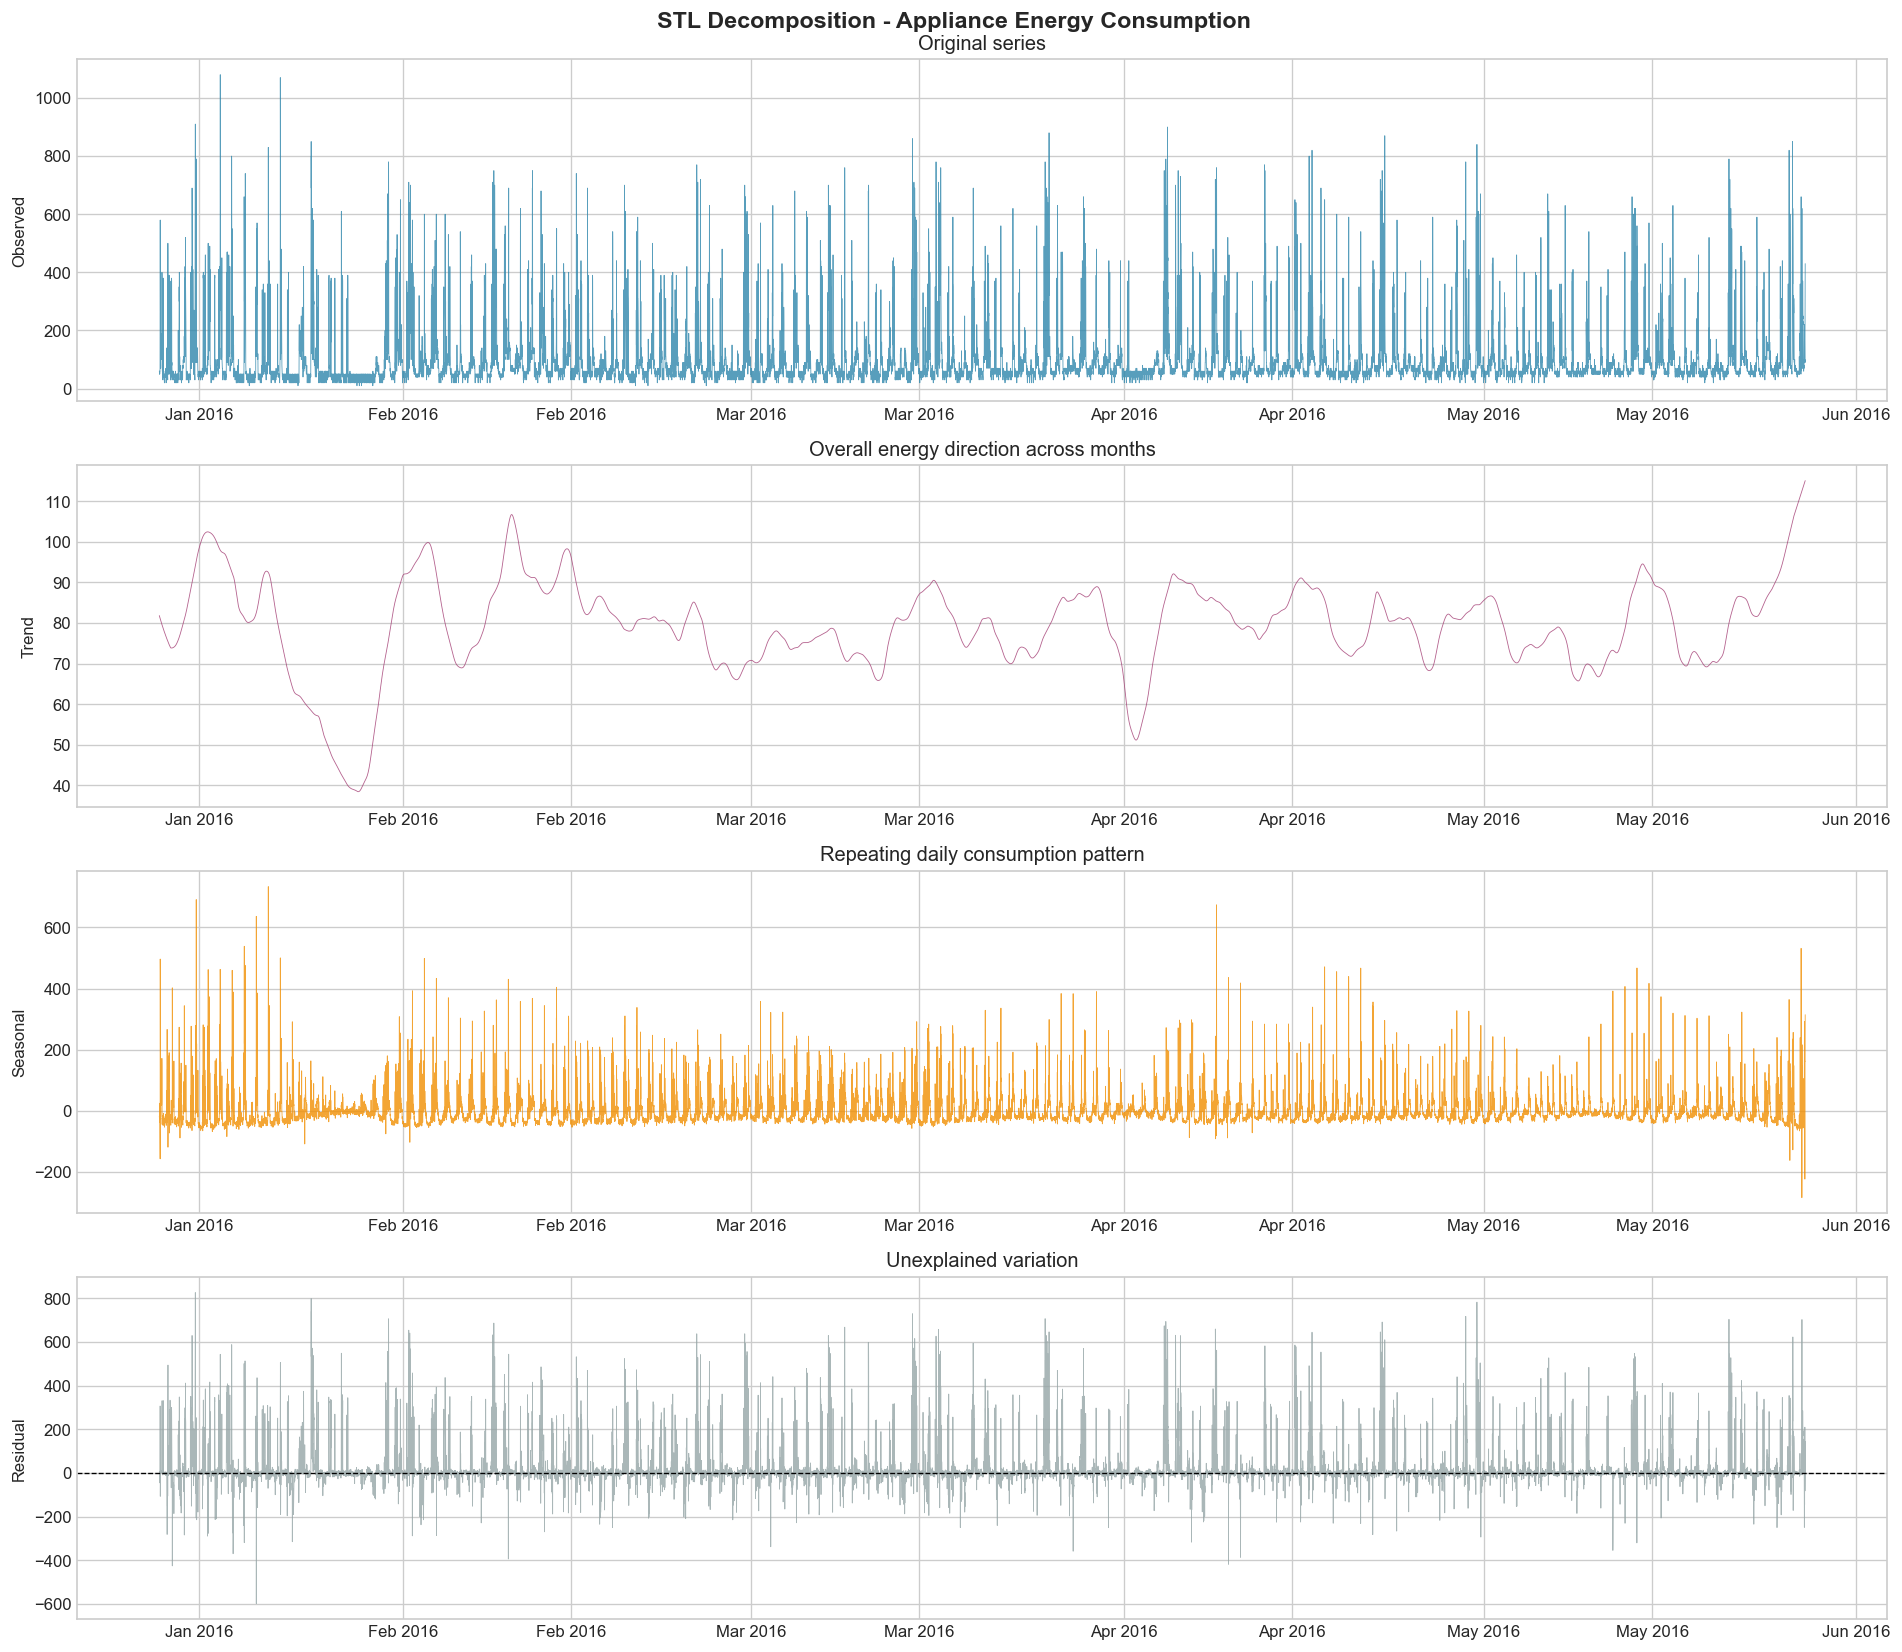

STL Component Summary:
  Trend range    : 38.5 to 115.0 Wh
  Seasonal range : -285.1 to 733.9 Wh
  Residual std   : 88.04 Wh

  The seasonal component confirms a strong daily repeating pattern.
  This justifies 144 steps (24 hours) as our primary look-back window candidate.


In [7]:
stl    = STL(df['Appliances'], period=144, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 14))
fig.suptitle('STL Decomposition - Appliance Energy Consumption',
             fontsize=14, fontweight='bold')

components = [
    (result.observed,  'Observed',  COLORS['primary'],   'Original series'),
    (result.trend,     'Trend',     COLORS['secondary'], 'Overall energy direction across months'),
    (result.seasonal,  'Seasonal',  COLORS['accent'],    'Repeating daily consumption pattern'),
    (result.resid,     'Residual',  COLORS['neutral'],   'Unexplained variation'),
]

for ax, (data, label, color, subtitle) in zip(axes, components):
    ax.plot(df['date'], data, color=color, linewidth=0.5, alpha=0.8)
    ax.set_ylabel(label)
    ax.set_title(subtitle)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    if label == 'Residual':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}02_stl_decomposition.png', bbox_inches='tight')
plt.show()

print("STL Component Summary:")
print(f"  Trend range    : {result.trend.min():.1f} to {result.trend.max():.1f} Wh")
print(f"  Seasonal range : {result.seasonal.min():.1f} to {result.seasonal.max():.1f} Wh")
print(f"  Residual std   : {result.resid.std():.2f} Wh")
print()
print("  The seasonal component confirms a strong daily repeating pattern.")
print("  This justifies 144 steps (24 hours) as our primary look-back window candidate.")

## 5. Temporal Patterns

We examine how consumption varies by hour of day, day of week, and weekday vs weekend.
These patterns directly inform which time-based features to engineer in the next notebook.


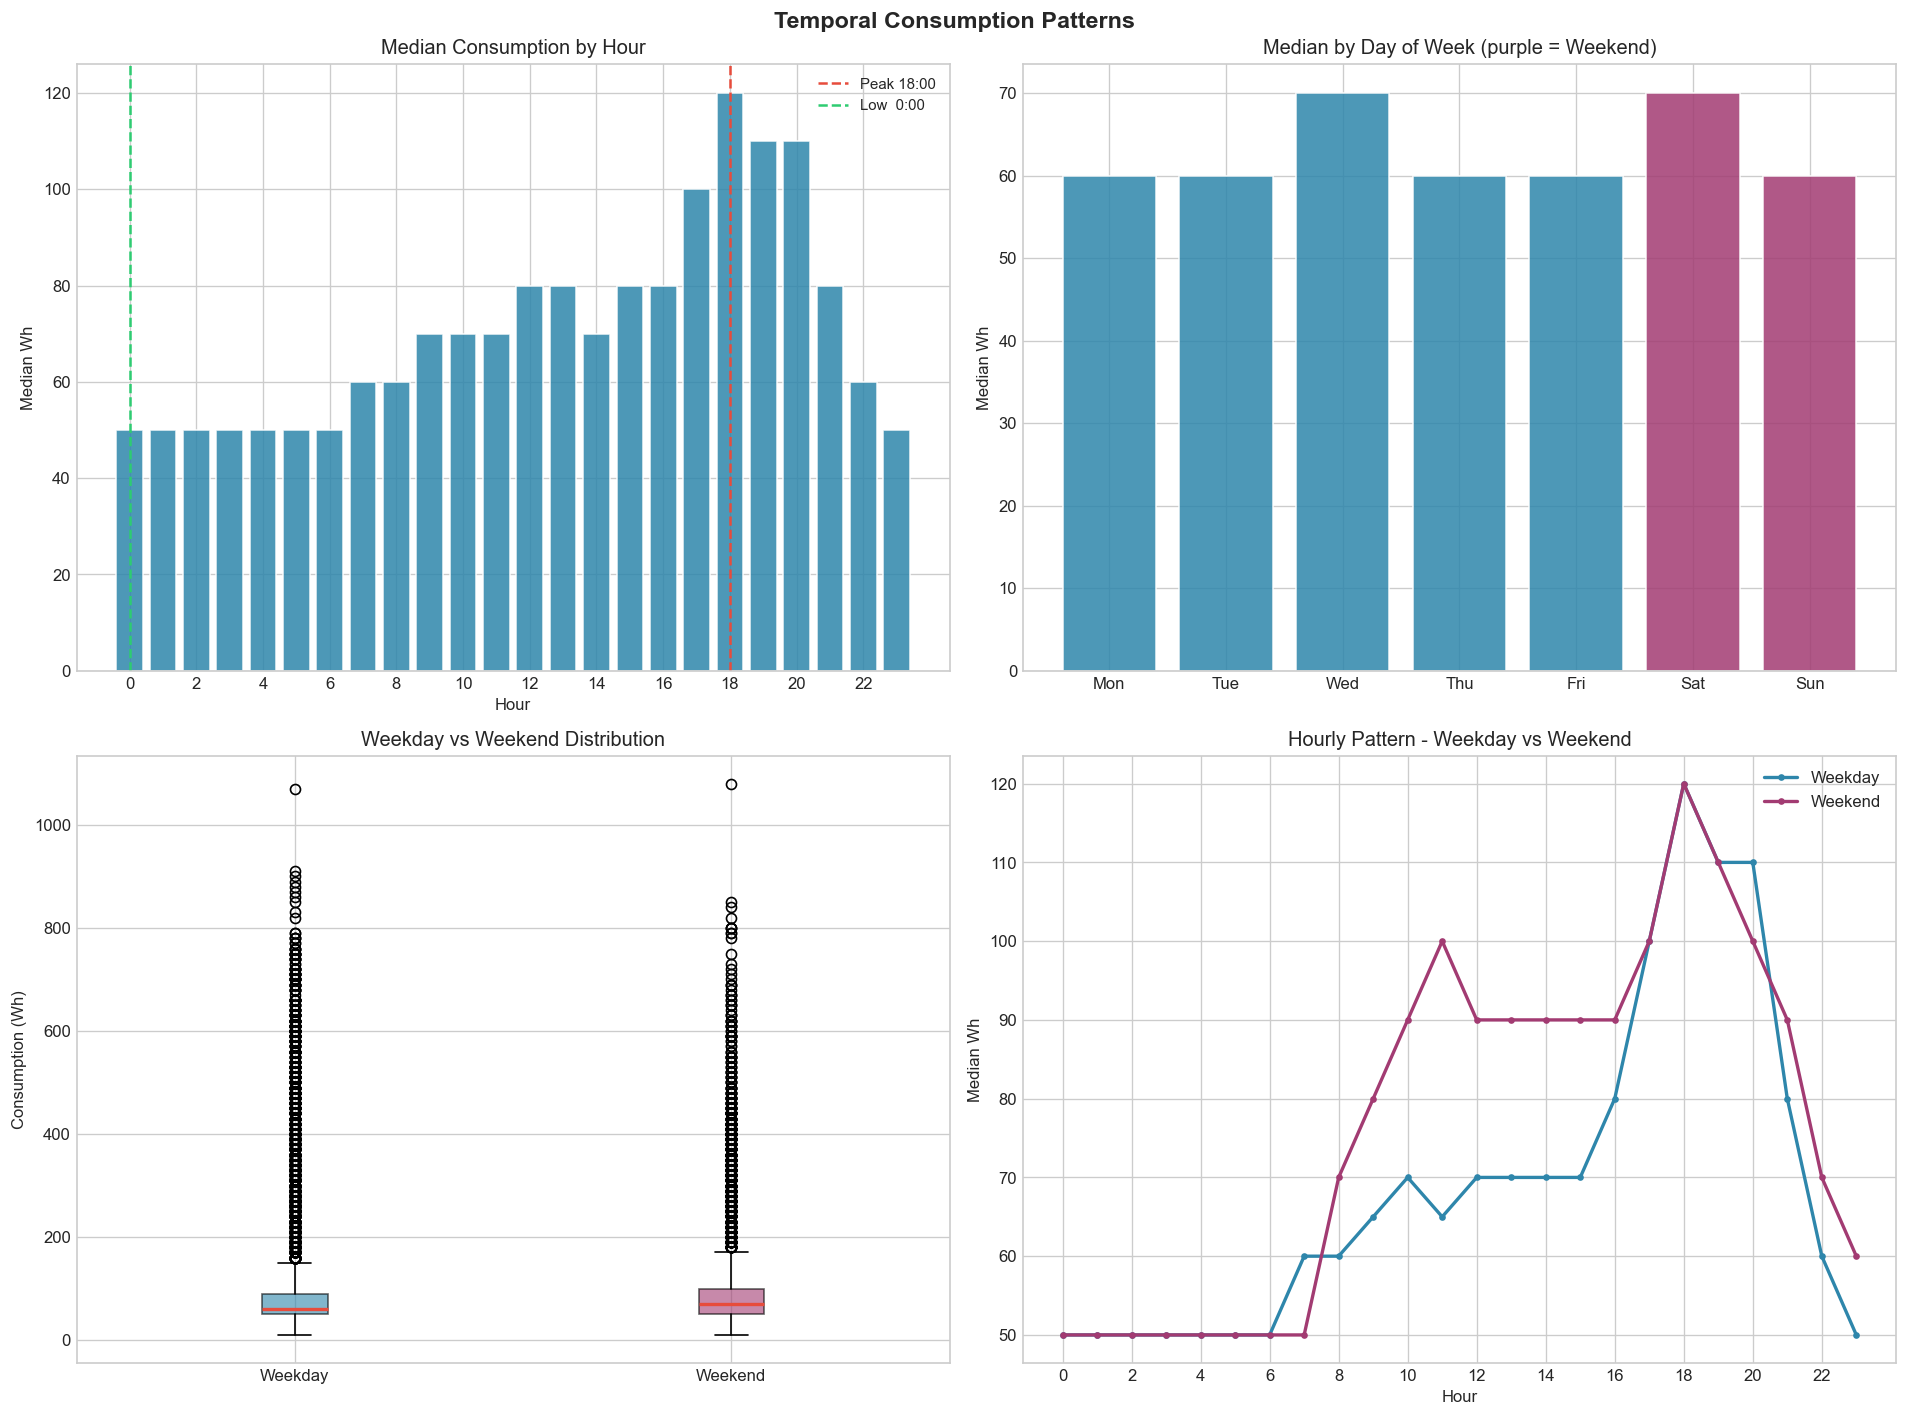

Peak hour    : 18:00  (120 Wh)
Trough hour  : 0:00  (50 Wh)
Weekday mean : 96.6 Wh
Weekend mean : 100.6 Wh


In [8]:
df = extract_time_features(df)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Temporal Consumption Patterns', fontsize=14, fontweight='bold')

# Hourly
hourly = df.groupby('hour')['Appliances'].median()
axes[0,0].bar(hourly.index, hourly.values,
              color=COLORS['primary'], alpha=0.85, edgecolor='white')
pk = hourly.idxmax()
tr = hourly.idxmin()
axes[0,0].axvline(pk, color=COLORS['danger'],  linestyle='--', linewidth=1.5, label=f'Peak {pk}:00')
axes[0,0].axvline(tr, color=COLORS['success'], linestyle='--', linewidth=1.5, label=f'Low  {tr}:00')
axes[0,0].set_title('Median Consumption by Hour')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Median Wh')
axes[0,0].set_xticks(range(0, 24, 2))
axes[0,0].legend(fontsize=9)

# Day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_data  = df.groupby(df['date'].dt.day_name())['Appliances'].median().reindex(day_order)
bar_c = [COLORS['secondary'] if d in ['Saturday','Sunday']
         else COLORS['primary'] for d in day_order]
axes[0,1].bar(range(7), day_data.values, color=bar_c, alpha=0.85, edgecolor='white')
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels([d[:3] for d in day_order])
axes[0,1].set_title('Median by Day of Week (purple = Weekend)')
axes[0,1].set_ylabel('Median Wh')

# Weekday vs weekend box
wkd = df[df['week_status']=='Weekday']['Appliances']
wke = df[df['week_status']=='Weekend']['Appliances']
bp = axes[1,0].boxplot([wkd, wke], labels=['Weekday','Weekend'],
                        patch_artist=True,
                        medianprops=dict(color=COLORS['danger'], linewidth=2))
bp['boxes'][0].set(facecolor=COLORS['primary'],   alpha=0.6)
bp['boxes'][1].set(facecolor=COLORS['secondary'], alpha=0.6)
axes[1,0].set_title('Weekday vs Weekend Distribution')
axes[1,0].set_ylabel('Consumption (Wh)')

# Hourly by type
for label, color in [('Weekday', COLORS['primary']), ('Weekend', COLORS['secondary'])]:
    h = df[df['week_status']==label].groupby('hour')['Appliances'].median()
    axes[1,1].plot(h.index, h.values, marker='o', markersize=3,
                   label=label, color=color, linewidth=2)
axes[1,1].set_title('Hourly Pattern - Weekday vs Weekend')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Median Wh')
axes[1,1].legend()
axes[1,1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}03_temporal_patterns.png', bbox_inches='tight')
plt.show()

print(f"Peak hour    : {pk}:00  ({hourly[pk]:.0f} Wh)")
print(f"Trough hour  : {tr}:00  ({hourly[tr]:.0f} Wh)")
print(f"Weekday mean : {wkd.mean():.1f} Wh")
print(f"Weekend mean : {wke.mean():.1f} Wh")

## 6. Correlation Analysis

Pearson correlation between all features and the target helps us:
- Identify the most predictive sensors
- Spot redundancy between features (e.g. highly correlated temperature rooms)
- Confirm that `rv1` and `rv2` carry no signal before dropping them

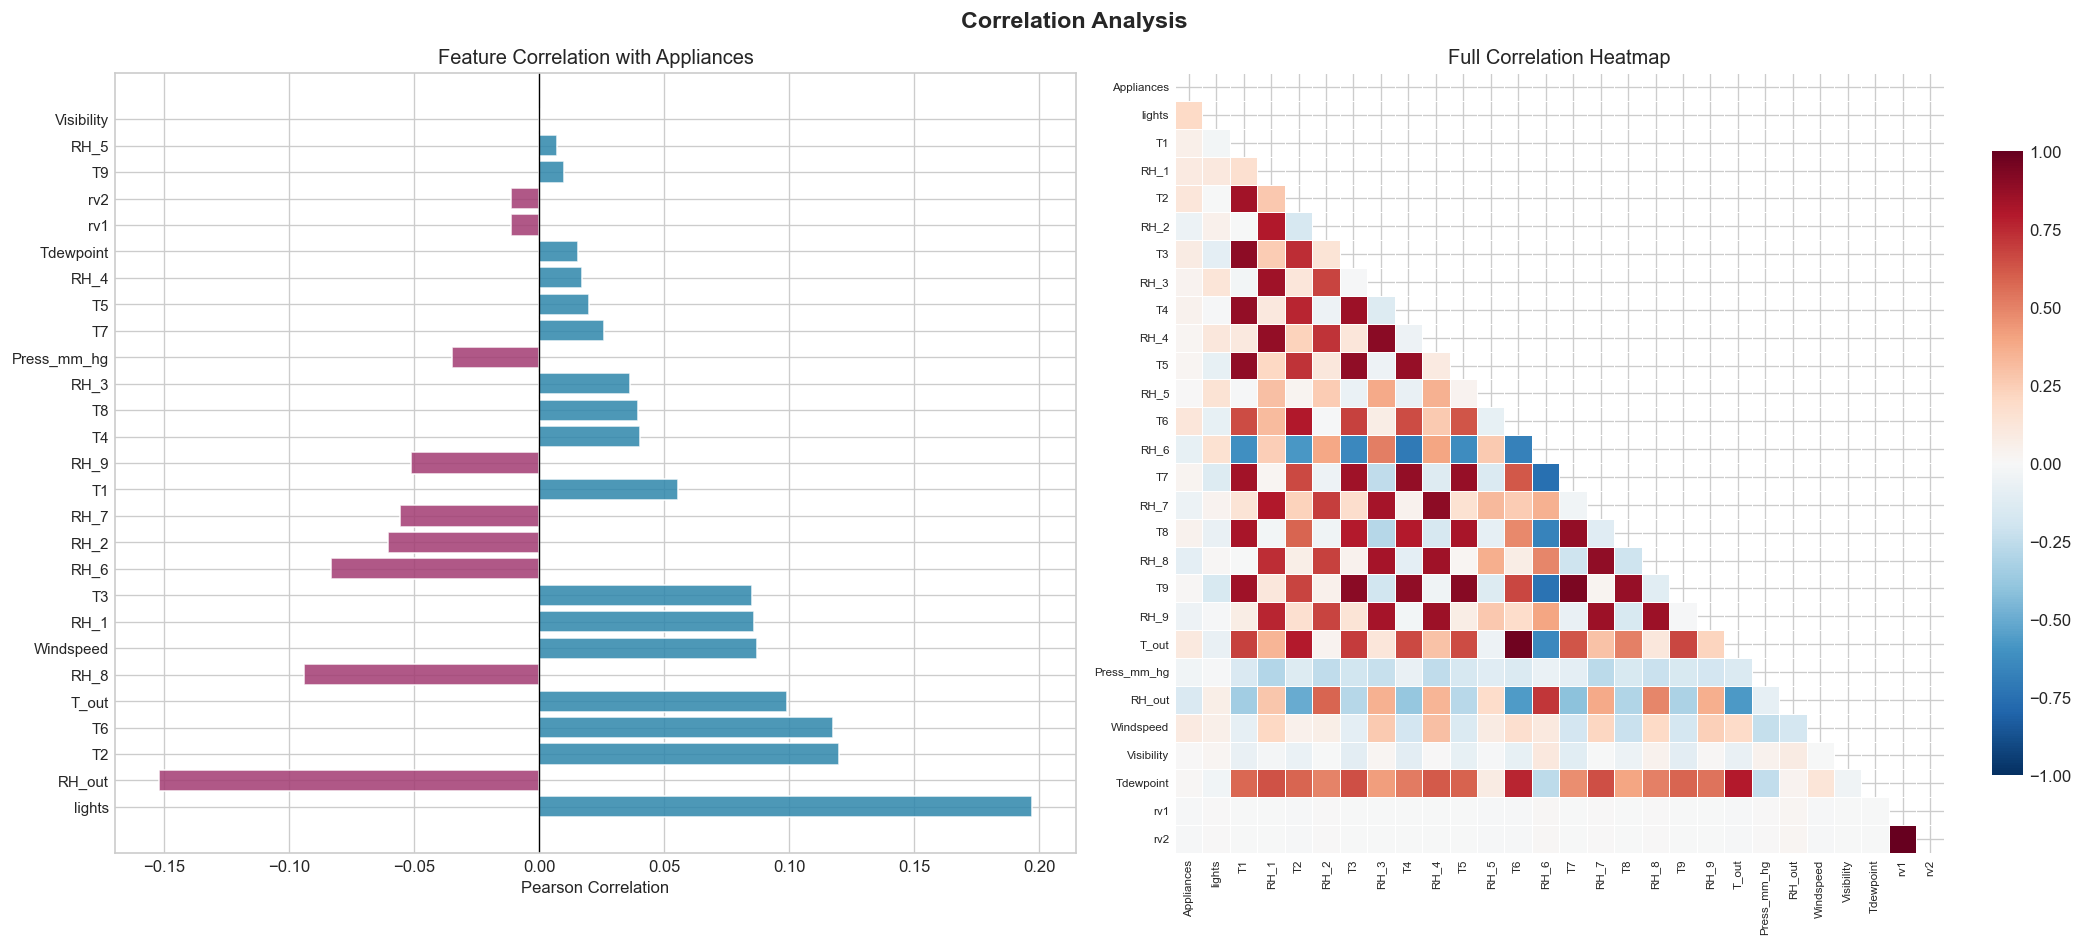

Top 10 features by absolute correlation with Appliances:
lights       0.1973
RH_out      -0.1523
T2           0.1201
T6           0.1176
T_out        0.0992
RH_8        -0.0940
Windspeed    0.0871
RH_1         0.0860
T3           0.0851
RH_6        -0.0832


In [9]:
num_df = df.select_dtypes(include=np.number).drop(
    columns=['hour','day_of_week','month','NSM'], errors='ignore')

corr_target = (num_df.corr()['Appliances']
               .drop('Appliances')
               .sort_values(key=abs, ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')

bar_colors = [COLORS['primary'] if v >= 0 else COLORS['secondary']
              for v in corr_target.values]
axes[0].barh(corr_target.index, corr_target.values,
             color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature Correlation with Appliances')
axes[0].set_xlabel('Pearson Correlation')
axes[0].tick_params(axis='y', labelsize=9)

mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))
sns.heatmap(num_df.corr(), mask=mask, ax=axes[1],
            cmap='RdBu_r', center=0, linewidths=0.3,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[1].set_title('Full Correlation Heatmap')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}04_correlation_analysis.png', bbox_inches='tight')
plt.show()

print("Top 10 features by absolute correlation with Appliances:")
print(corr_target.head(10).round(4).to_string())

## 7. Feature Distributions

Understanding the distribution shape of each sensor group tells us which
scaling strategy is appropriate:

- If features are **normally distributed** - StandardScaler is appropriate  
- If features are **bounded or skewed** - MinMaxScaler would be considered

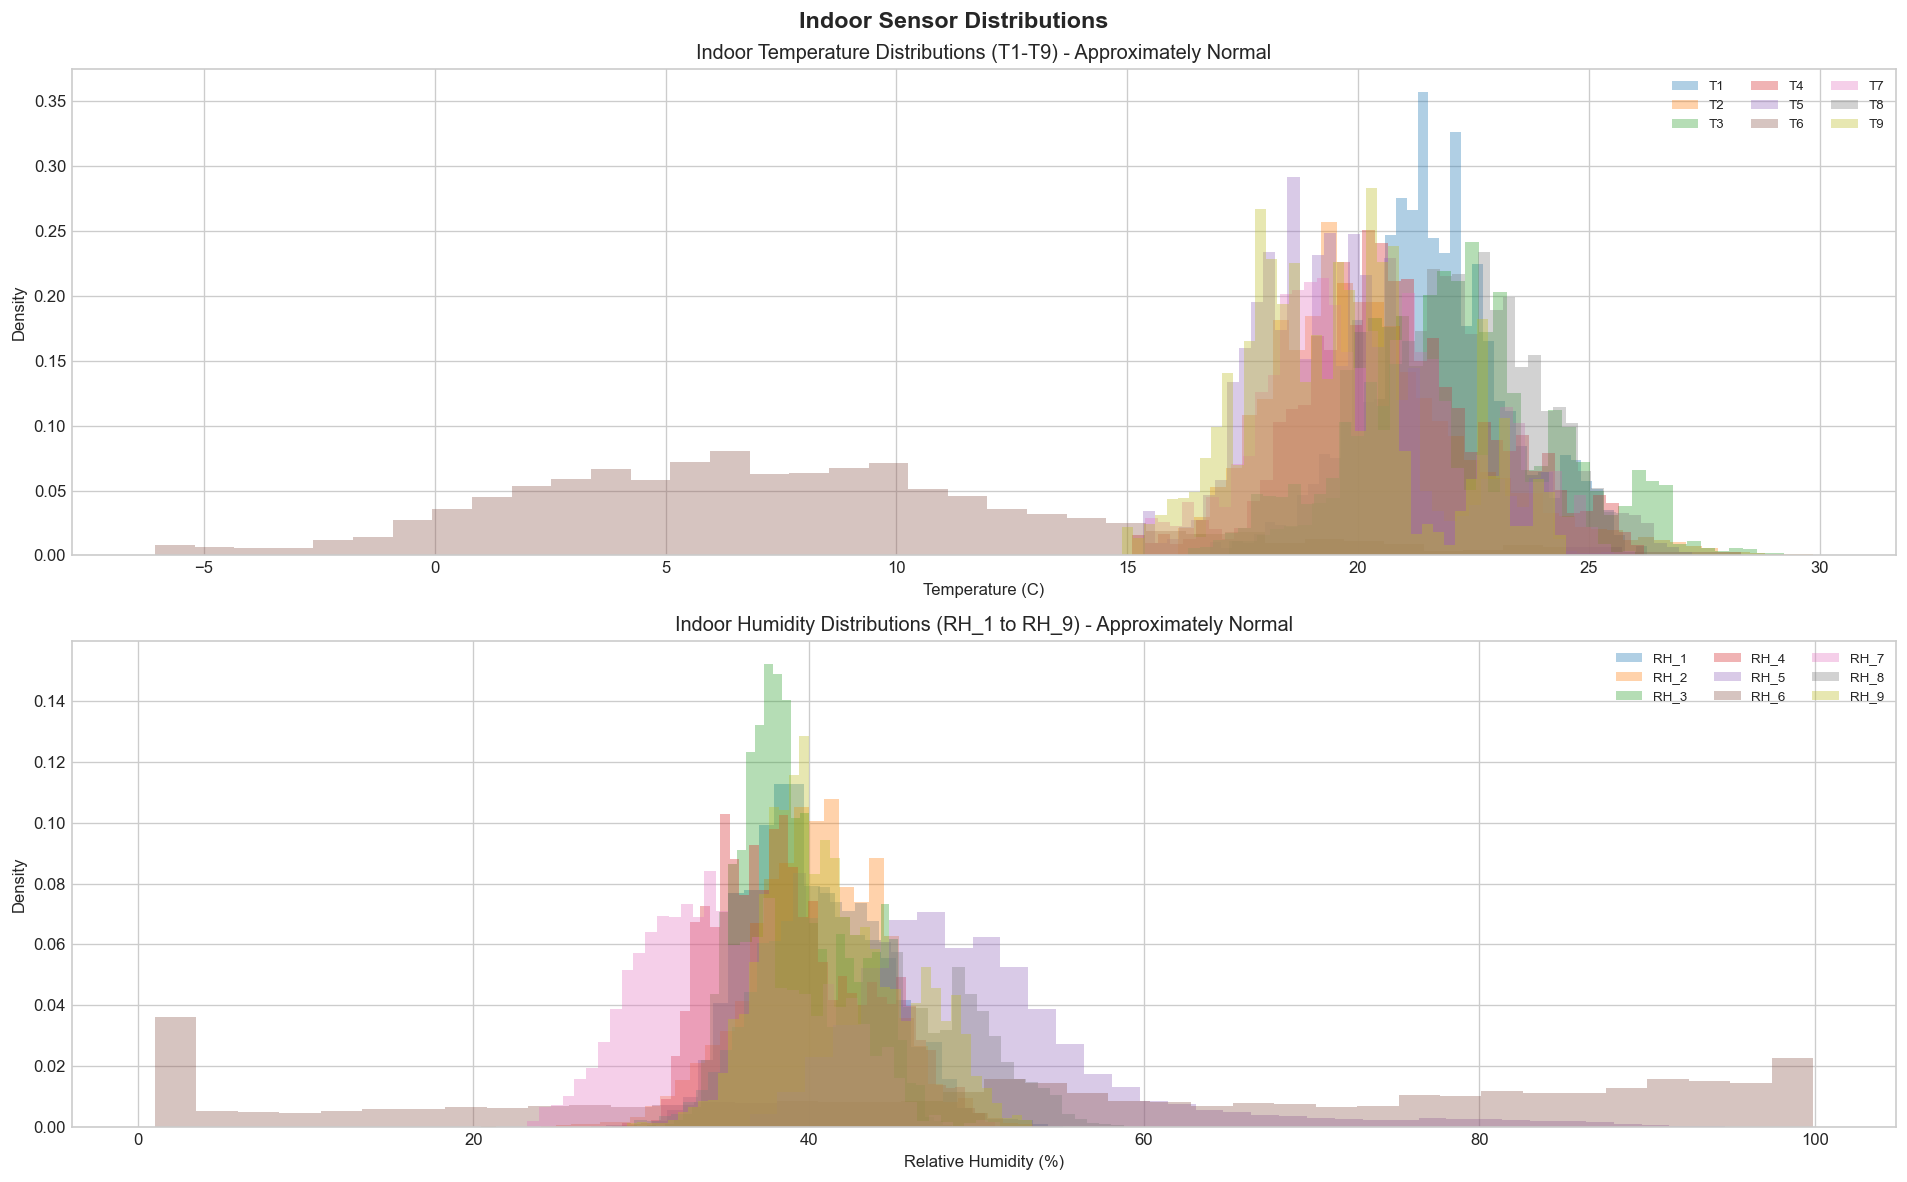

Observations:
  T1-T5, T7-T9 : approximately normally distributed (indoor rooms)
  T6            : flat/uniform distribution, -5 to 12C - outdoor-adjacent sensor
  RH_1 to RH_9 : approximately normal with mild right skew in some sensors

Decision: StandardScaler for all input features.
  Handles each feature independently by its own mean and std.
  T6's uniform shape is valid input - no scaler change needed.
  T6 flagged as outdoor-adjacent in the report.


In [16]:
temp_cols  = [c for c in df.columns if c.startswith('T') and c not in ['T_out','Tdewpoint']]
humid_cols = [c for c in df.columns if c.startswith('RH') and c != 'RH_out']

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Indoor Sensor Distributions', fontsize=14, fontweight='bold')

for col in temp_cols:
    axes[0].hist(df[col], bins=40, alpha=0.35, label=col, density=True)
axes[0].set_title('Indoor Temperature Distributions (T1-T9) - Approximately Normal')
axes[0].set_xlabel('Temperature (C)')
axes[0].set_ylabel('Density')
axes[0].legend(loc='upper right', fontsize=8, ncol=3)

for col in humid_cols:
    axes[1].hist(df[col], bins=40, alpha=0.35, label=col, density=True)
axes[1].set_title('Indoor Humidity Distributions (RH_1 to RH_9) - Approximately Normal')
axes[1].set_xlabel('Relative Humidity (%)')
axes[1].set_ylabel('Density')
axes[1].legend(loc='upper right', fontsize=8, ncol=3)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}05_indoor_distributions.png', bbox_inches='tight')
plt.show()


print("Observations:")
print("  T1-T5, T7-T9 : approximately normally distributed (indoor rooms)")
print("  T6            : flat/uniform distribution, -5 to 12C - outdoor-adjacent sensor")
print("  RH_1 to RH_9 : approximately normal with mild right skew in some sensors")
print()
print("Decision: StandardScaler for all input features.")
print("  Handles each feature independently by its own mean and std.")
print("  T6's uniform shape is valid input - no scaler change needed.")
print("  T6 flagged as outdoor-adjacent in the report.")

## 8. Outlier Detection and Treatment

**Method used:** IQR (Interquartile Range) - standard and interpretable  
**Decision: CLIP at the upper fence, do not remove rows**

Removing rows from a time series creates gaps in the index. Any rolling averages
or lag features computed after the deletion would produce NaN values or incorrect
lookbacks. Clipping preserves all rows while capping extreme values.

=== IQR OUTLIER ANALYSIS ===
  Q1                  : 50.0
  Q3                  : 100.0
  IQR                 : 50.0
  upper_fence         : 175.0
  lower_fence         : 0
  outliers_high       : 2138
  outliers_low        : 0


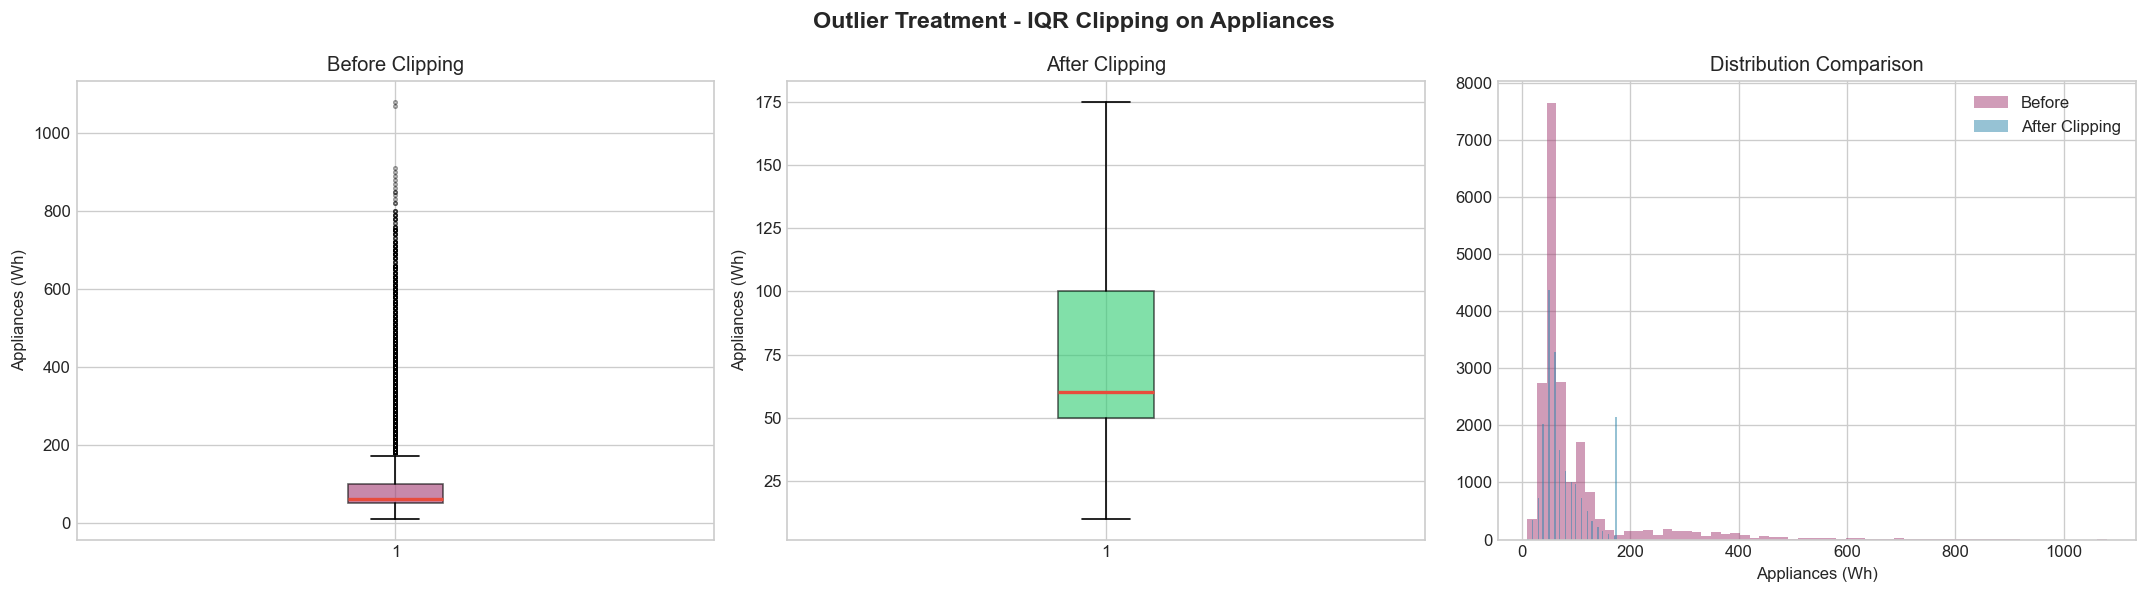

In [11]:
df_clipped, outlier_stats = clip_outliers_iqr(df, column='Appliances')

print("=== IQR OUTLIER ANALYSIS ===")
for k, v in outlier_stats.items():
    print(f"  {k:<20}: {v}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Outlier Treatment - IQR Clipping on Appliances', fontsize=14, fontweight='bold')

for ax, data, title, color in zip(
    [axes[0], axes[1]],
    [df['Appliances'], df_clipped['Appliances']],
    ['Before Clipping', 'After Clipping'],
    [COLORS['secondary'], COLORS['success']]
):
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color=COLORS['danger'], linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4))
    bp['boxes'][0].set(facecolor=color, alpha=0.6)
    ax.set_title(title)
    ax.set_ylabel('Appliances (Wh)')

axes[2].hist(df['Appliances'],         bins=60, alpha=0.5,
             color=COLORS['secondary'], label='Before')
axes[2].hist(df_clipped['Appliances'], bins=60, alpha=0.5,
             color=COLORS['primary'],   label='After Clipping')
axes[2].set_title('Distribution Comparison')
axes[2].set_xlabel('Appliances (Wh)')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}06_outlier_treatment.png', bbox_inches='tight')
plt.show()

## 9. ACF and PACF Analysis

**ACF (Autocorrelation Function):** How correlated is the series with its own past values?  
**PACF (Partial ACF):** Same, but after removing the effect of intermediate lags.

These plots serve two purposes here:
1. Identify which lag values carry independent predictive signal - guides lag feature selection
2. Show how far back autocorrelation remains significant - guides sequence window selection


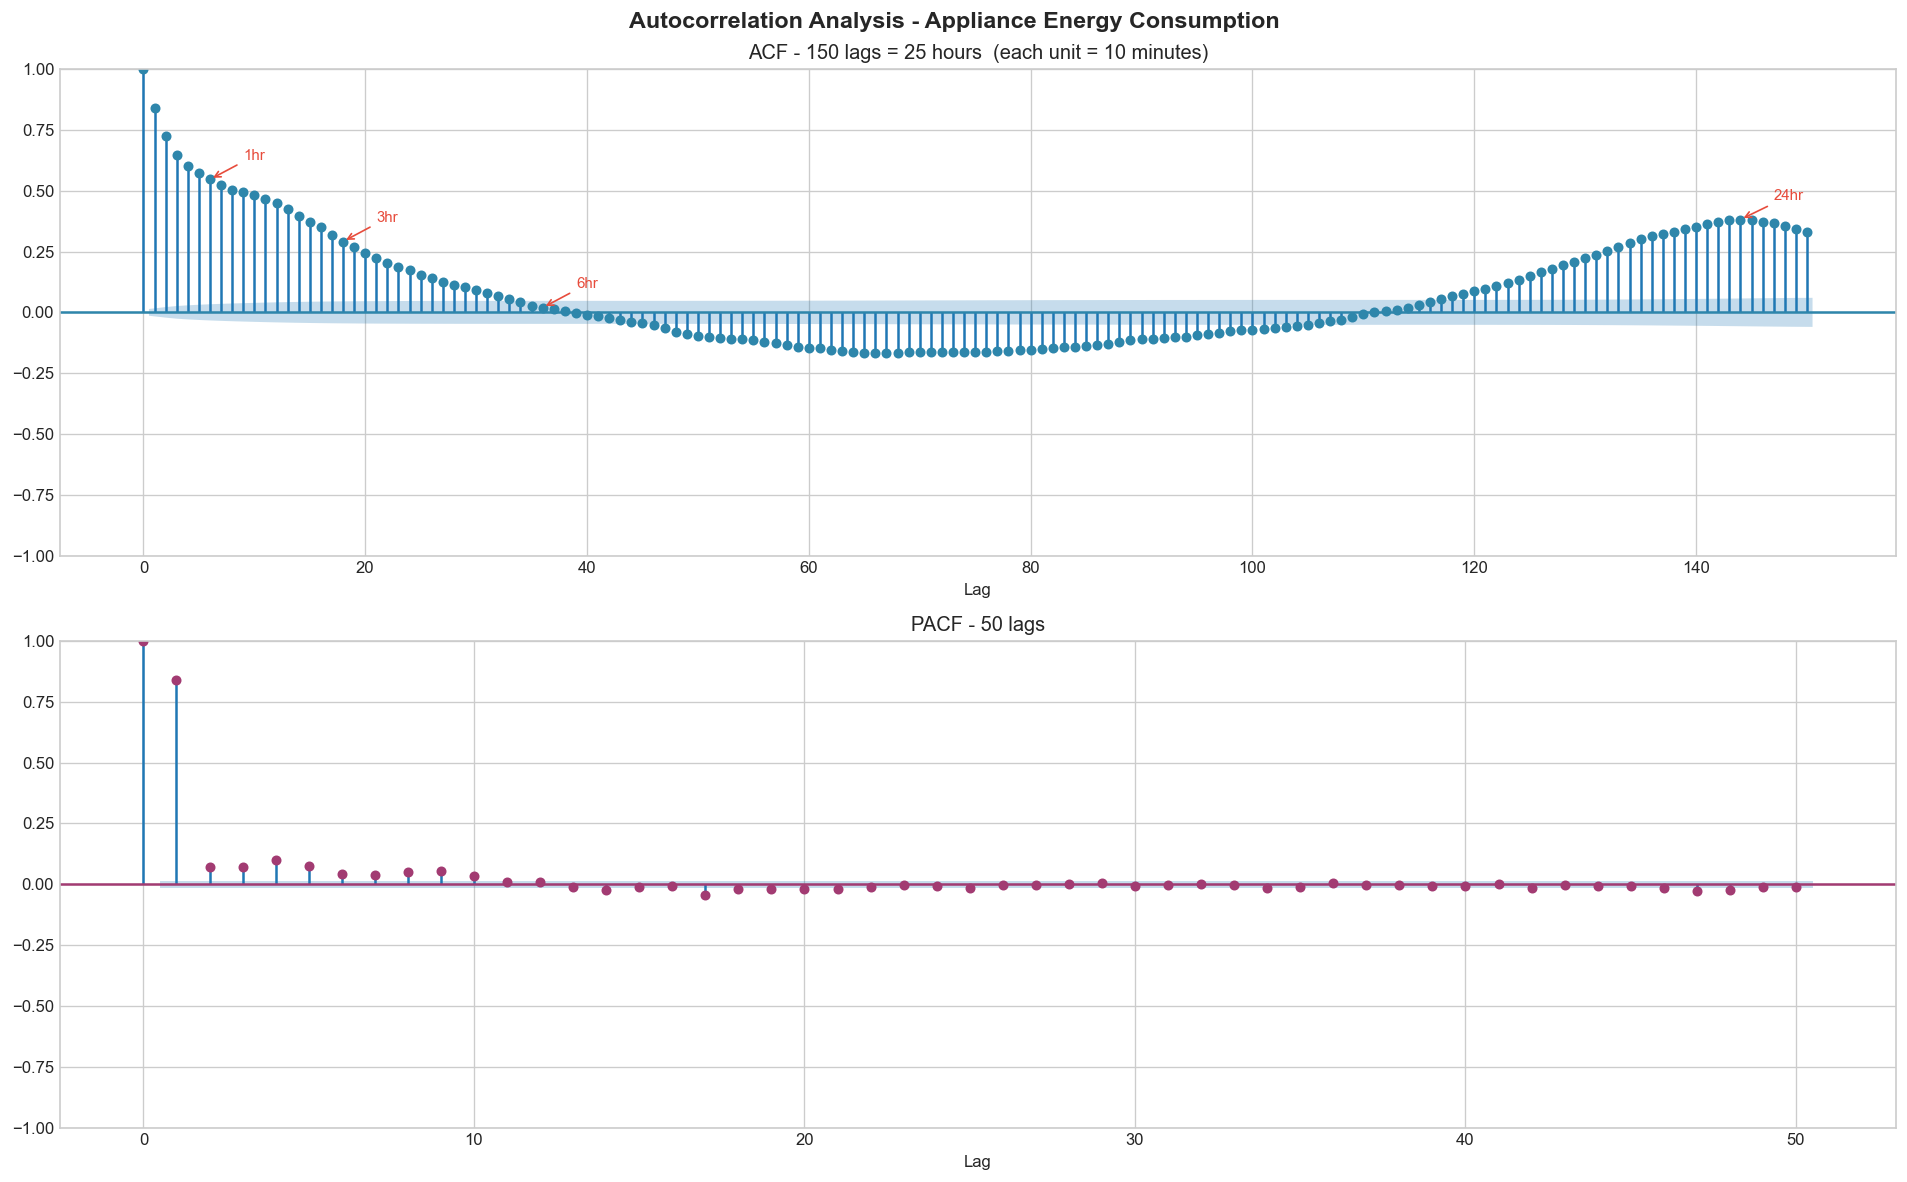

ACF values at candidate lag positions:
  Lag   Duration      ACF
-------------------------
  1     10min      0.8405
  3     30min      0.6482
  6     1hr        0.5467
  18    3hr        0.2913
  36    6hr        0.0193
  144   24hr       0.3818

Lag features selected   : 1, 3, 6, 18, 36, 144
Window candidates       : 24 steps (4hr), 72 steps (12hr), 144 steps (24hr)
Window selection method : treat as hyperparameter, pick via validation loss


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Autocorrelation Analysis - Appliance Energy Consumption',
             fontsize=14, fontweight='bold')

plot_acf(df_clipped['Appliances'],  lags=150, ax=axes[0],
         color=COLORS['primary'],  alpha=0.05)
axes[0].set_title('ACF - 150 lags = 25 hours  (each unit = 10 minutes)')
axes[0].set_xlabel('Lag')

plot_pacf(df_clipped['Appliances'], lags=50, ax=axes[1],
          color=COLORS['secondary'], alpha=0.05, method='ywm')
axes[1].set_title('PACF - 50 lags')
axes[1].set_xlabel('Lag')

# Annotate candidate lags on ACF
acf_vals = acf(df_clipped['Appliances'], nlags=150)
for lag, label in [(6,'1hr'), (18,'3hr'), (36,'6hr'), (144,'24hr')]:
    if lag <= 150:
        axes[0].annotate(
            label,
            xy=(lag, acf_vals[lag]),
            xytext=(lag + 3, min(acf_vals[lag] + 0.08, 0.95)),
            fontsize=9, color=COLORS['danger'],
            arrowprops=dict(arrowstyle='->', color=COLORS['danger'])
        )

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}07_acf_pacf.png', bbox_inches='tight')
plt.show()

print("ACF values at candidate lag positions:")
print(f"  {'Lag':<5} {'Duration':<8} {'ACF':>8}")
print("-" * 25)
for lag, label in [(1,'10min'),(3,'30min'),(6,'1hr'),(18,'3hr'),(36,'6hr'),(144,'24hr')]:
    if lag < len(acf_vals):
        print(f"  {lag:<5} {label:<8} {acf_vals[lag]:>8.4f}")

print()
print("Lag features selected   : 1, 3, 6, 18, 36, 144")
print("Window candidates       : 24 steps (4hr), 72 steps (12hr), 144 steps (24hr)")
print("Window selection method : treat as hyperparameter, pick via validation loss")

## 10. EDA Summary and Key Decisions

| Finding | Decision |
|---|---|
| No missing values | No imputation required |
| No duplicate rows | No deduplication required |
| `rv1` identical to `rv2`, near-zero correlation with target | Drop both columns |
| Extra columns T7-T9, RH_7-RH_9, Tdewpoint present | Keep all - additional sensor coverage |
| NSM, WeekStatus, Day_of_week absent from dataset | Engineered from date column |
| Target skewness = 3.39, right-skewed with spikes | Huber Loss primary, MSE as comparison experiment |
| Outliers above IQR upper fence (2.16% of rows) | Clip at upper fence - do not remove rows |
| Most indoor sensors approximately normal; T6 is flat/uniform (-5 to 12C) | StandardScaler for all input features - handles any distribution shape independently |
| Target needs bounded 0-1 output range | MinMaxScaler for Appliances only, after clipping |
| STL confirms strong daily seasonal cycle (period=144) | 144-step window as primary candidate |
| Large STL residuals | Stochastic consumption behaviour - model will not achieve perfect predictions |
| ACF U-shape confirms daily seasonality; lag 144 ACF ~0.35 | Sequence window candidates: 24, 72, 144 steps (treat as hyperparameter) |
| ACF at lag 36 (6hr) near zero/slightly negative | Lag 36 retained - captures phase information of daily cycle |
| PACF significant only at lag 1-2 (AR(1) structure) | Short lags 1 and 3 are most individually predictive |
| Lag features confirmed by ACF/PACF | Lags at steps 1, 3, 6, 18, 36, 144 |
| Weekday vs Weekend behavioral difference | `week_status` as engineered feature |
| Weekend midday peak (11:00-12:00) absent on weekdays | Add weekend x hour interaction feature in Feature Engineering |

In [17]:
# Drop noise columns and save the cleaned interim file for Feature Engineering notebook
df_out = drop_noise_columns(df_clipped)
df_out = df_out.round(4)

save_path = f'{PROCESSED_PATH}01_after_eda.csv'
df_out.to_csv(save_path, index=False)

print(f"Saved  : {save_path}")
print(f"Shape  : {df_out.shape}")
print(f"Columns dropped : rv1, rv2")
print()

Saved  : ../data/processed/01_after_eda.csv
Shape  : (19735, 32)
Columns dropped : rv1, rv2

